In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

FIG_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5"
TAB_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Figure dir:", FIG_DIR)
print("Table dir:", TAB_DIR)

Figure dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5
Table dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5


In [3]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import re
import types
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_EXPLAIN_DIR = f"{PROJECT_ROOT}/outputs/explainability"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

TRANSFORMER_DIR = f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y"
OUTPUTS_EXPLAIN_AVG_DIR = f"{OUTPUTS_EXPLAIN_DIR}/attention_average_5y"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_EXPLAIN_DIR,
    OUTPUTS_EXPLAIN_AVG_DIR,
    CONFIGS_DIR,
    TRANSFORMER_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("TRANSFORMER_DIR:", TRANSFORMER_DIR)
print("OUTPUTS_EXPLAIN_AVG_DIR:", OUTPUTS_EXPLAIN_AVG_DIR)
print("ASSETS:", ASSETS)
print("LOOKBACK:", LOOKBACK)
print("device:", device)

TRANSFORMER_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y
OUTPUTS_EXPLAIN_AVG_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y
ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
LOOKBACK: 20
device: cpu


In [5]:
# ============================================================
# CELL 04 — Load 5Y test data
# ============================================================

env_ready_5y = np.load(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz", allow_pickle=True)

X_test = env_ready_5y["X_test"].astype(np.float32)
y_test = env_ready_5y["y_test"].astype(np.float32)
dates_test = env_ready_5y["dates_test"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("dates_test:", dates_test.shape)

X_test: (251, 20, 5, 13)
y_test: (251, 5)
dates_test: (251,)


In [6]:
# ============================================================
# CELL 05 — Find checkpoint
# ============================================================

candidate_names = [
    "best_model.pt",
    "best_model.pth",
    "model_best.pt",
    "model_best.pth",
    "best_checkpoint.pt",
    "best_checkpoint.pth",
    "checkpoint_best.pt",
    "checkpoint_best.pth",
    "final_model.pt",
    "final_model.pth",
]

existing = []
for name in candidate_names:
    fp = os.path.join(TRANSFORMER_DIR, name)
    if os.path.exists(fp):
        existing.append(fp)

if len(existing) == 0:
    all_ckpts = sorted(
        [str(p) for p in Path(TRANSFORMER_DIR).glob("*.pt")] +
        [str(p) for p in Path(TRANSFORMER_DIR).glob("*.pth")]
    )
else:
    all_ckpts = existing

print("Checkpoint candidates found:")
for fp in all_ckpts:
    print(" -", fp)

assert len(all_ckpts) > 0, "No checkpoint file found in transformer_ppo_final_5y folder."

CHECKPOINT_PATH = all_ckpts[0]
print("\nUsing checkpoint:", CHECKPOINT_PATH)

Checkpoint candidates found:
 - /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y/best_model.pt

Using checkpoint: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y/best_model.pt


In [7]:
# ============================================================
# CELL 06 — Read checkpoint and infer encoder config
# ============================================================

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

if isinstance(ckpt, dict) and all(isinstance(k, str) for k in ckpt.keys()):
    state_dict = ckpt
else:
    raise RuntimeError("Checkpoint format not supported for state_dict loading.")

print("Checkpoint python type:", type(state_dict))
print("First 20 keys:", list(state_dict.keys())[:20])

assert "encoder.input_proj.weight" in state_dict, "Missing encoder.input_proj.weight"

d_model, input_dim = state_dict["encoder.input_proj.weight"].shape

layer_ids = []
for k in state_dict.keys():
    m = re.match(r"encoder\.transformer\.layers\.(\d+)\.", k)
    if m:
        layer_ids.append(int(m.group(1)))
num_layers = max(layer_ids) + 1 if layer_ids else 1

ff_key = "encoder.transformer.layers.0.linear1.weight"
assert ff_key in state_dict, f"Missing {ff_key}"
dim_feedforward = state_dict[ff_key].shape[0]

candidate_cfgs = []
candidate_cfgs.extend(sorted([str(p) for p in Path(TRANSFORMER_DIR).glob("*.json")]))
candidate_cfgs.extend(sorted([str(p) for p in Path(CONFIGS_DIR).glob("*.json")]))

cfg_found = {}
for fp in candidate_cfgs:
    try:
        with open(fp, "r") as f:
            obj = json.load(f)
        if isinstance(obj, dict):
            cfg_found[fp] = obj
    except Exception:
        pass

def recursive_find_key(d, target_keys):
    if isinstance(d, dict):
        for k, v in d.items():
            if k in target_keys:
                return v
            out = recursive_find_key(v, target_keys)
            if out is not None:
                return out
    return None

nhead = None
dropout = None
activation = "gelu"

for fp, obj in cfg_found.items():
    if nhead is None:
        nhead = recursive_find_key(obj, {"nhead", "num_heads"})
    if dropout is None:
        dropout = recursive_find_key(obj, {"dropout", "transformer_dropout"})
    act = recursive_find_key(obj, {"activation"})
    if act is not None:
        activation = act

if nhead is None:
    candidate_heads = [8, 4, 2, 1]
    valid = [h for h in candidate_heads if d_model % h == 0]
    nhead = valid[0] if len(valid) > 0 else 1

if dropout is None:
    dropout = 0.1

pe_key = "encoder.pos_encoder.pe"
assert pe_key in state_dict, f"Missing {pe_key} in checkpoint"

if state_dict[pe_key].ndim == 3:
    checkpoint_max_len = int(state_dict[pe_key].shape[1])
elif state_dict[pe_key].ndim == 2:
    checkpoint_max_len = int(state_dict[pe_key].shape[0])
else:
    raise RuntimeError(f"Unsupported positional encoding shape: {state_dict[pe_key].shape}")

print("input_dim:", input_dim)
print("d_model:", d_model)
print("num_layers:", num_layers)
print("dim_feedforward:", dim_feedforward)
print("nhead:", nhead)
print("dropout:", dropout)
print("activation:", activation)
print("checkpoint_max_len:", checkpoint_max_len)
print("input test sequence length:", X_test.shape[1])

Checkpoint python type: <class 'collections.OrderedDict'>
First 20 keys: ['encoder.input_proj.weight', 'encoder.input_proj.bias', 'encoder.pos_encoder.pe', 'encoder.transformer.layers.0.self_attn.in_proj_weight', 'encoder.transformer.layers.0.self_attn.in_proj_bias', 'encoder.transformer.layers.0.self_attn.out_proj.weight', 'encoder.transformer.layers.0.self_attn.out_proj.bias', 'encoder.transformer.layers.0.linear1.weight', 'encoder.transformer.layers.0.linear1.bias', 'encoder.transformer.layers.0.linear2.weight', 'encoder.transformer.layers.0.linear2.bias', 'encoder.transformer.layers.0.norm1.weight', 'encoder.transformer.layers.0.norm1.bias', 'encoder.transformer.layers.0.norm2.weight', 'encoder.transformer.layers.0.norm2.bias', 'encoder.transformer.layers.1.self_attn.in_proj_weight', 'encoder.transformer.layers.1.self_attn.in_proj_bias', 'encoder.transformer.layers.1.self_attn.out_proj.weight', 'encoder.transformer.layers.1.self_attn.out_proj.bias', 'encoder.transformer.layers.1.li

In [8]:
# ============================================================
# CELL 07 — Define encoder
# ============================================================

class PositionalEncodingFlexible(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 25):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(1, max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))

        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe, persistent=True)

    def forward(self, x):
        x = x + self.pe[:, :x.shape[1], :]
        return self.dropout(x)


class TransformerStateEncoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        dim_feedforward: int,
        dropout: float = 0.1,
        activation: str = "gelu",
        max_len: int = 25,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncodingFlexible(
            d_model=d_model,
            dropout=dropout,
            max_len=max_len,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation=activation,
            batch_first=True,
            norm_first=False,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

    def forward(self, x):
        # x: [B, L, N, F]
        b, l, n, f = x.shape
        x = x.reshape(b, l, n * f)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return x

In [9]:
# ============================================================
# CELL 08 — Build encoder and load weights
# ============================================================

encoder_model = TransformerStateEncoder(
    input_dim=input_dim,
    d_model=d_model,
    nhead=int(nhead),
    num_layers=int(num_layers),
    dim_feedforward=int(dim_feedforward),
    dropout=float(dropout),
    activation=str(activation),
    max_len=int(checkpoint_max_len),
).to(device)

encoder_state = {}
for k, v in state_dict.items():
    if k.startswith("encoder."):
        new_k = k[len("encoder."):]
        encoder_state[new_k] = v

missing, unexpected = encoder_model.load_state_dict(encoder_state, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

encoder_model.eval()
print(encoder_model)

Missing keys: []
Unexpected keys: ['post.0.weight', 'post.0.bias']
TransformerStateEncoder(
  (input_proj): Linear(in_features=65, out_features=128, bias=True)
  (pos_encoder): PositionalEncodingFlexible(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
)


In [10]:
# ============================================================
# CELL 09 — Patch encoder layers for attention extraction
# ============================================================

def patch_transformer_encoder_layers(root_model: nn.Module):
    patched_count = 0

    for module in root_model.modules():
        if isinstance(module, nn.TransformerEncoderLayer):
            def wrapped_sa_block(self, x, attn_mask, key_padding_mask, is_causal=False):
                attn_output, attn_weights = self.self_attn(
                    x, x, x,
                    attn_mask=attn_mask,
                    key_padding_mask=key_padding_mask,
                    need_weights=True,
                    average_attn_weights=False,
                    is_causal=is_causal,
                )
                self._last_attn_weights = attn_weights.detach().cpu()
                return self.dropout1(attn_output)

            module._sa_block = types.MethodType(wrapped_sa_block, module)
            patched_count += 1

    return patched_count

patched_count = patch_transformer_encoder_layers(encoder_model)
print("Patched TransformerEncoderLayer blocks:", patched_count)

assert patched_count > 0, "No nn.TransformerEncoderLayer found."

Patched TransformerEncoderLayer blocks: 2


In [11]:
# ============================================================
# CELL 10 — Disable fastpath and use train mode for inspection
# ============================================================

try:
    torch.backends.mha.set_fastpath_enabled(False)
    print("Disabled torch MHA fastpath.")
except Exception as e:
    print("Could not disable MHA fastpath:", repr(e))

encoder_model.train()
print("encoder_model.training =", encoder_model.training)

Disabled torch MHA fastpath.
encoder_model.training = True


In [12]:
# ============================================================
# CELL 11 — Helper functions
# ============================================================

def extract_attention_stack_from_layers(model: nn.Module):
    stacks = []
    names = []

    for name, module in model.named_modules():
        if isinstance(module, nn.TransformerEncoderLayer):
            attn = getattr(module, "_last_attn_weights", None)
            if attn is not None:
                if attn.ndim == 4:
                    attn_np = attn[0].mean(dim=0).detach().cpu().numpy()
                elif attn.ndim == 3:
                    attn_np = attn[0].detach().cpu().numpy()
                else:
                    continue

                stacks.append(attn_np)
                names.append(name)

    return names, stacks


def build_aggregate_attention(attn_stack):
    min_tgt = min(a.shape[0] for a in attn_stack)
    min_src = min(a.shape[1] for a in attn_stack)
    cropped = [a[:min_tgt, :min_src] for a in attn_stack]
    agg = np.mean(np.stack(cropped, axis=0), axis=0)
    return agg


def run_attention_for_index(idx: int):
    for module in encoder_model.modules():
        if isinstance(module, nn.TransformerEncoderLayer) and hasattr(module, "_last_attn_weights"):
            module._last_attn_weights = None

    x_np = X_test[idx:idx+1]
    x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device)

    _ = encoder_model(x_tensor)

    layer_names, attn_stack = extract_attention_stack_from_layers(encoder_model)
    assert len(attn_stack) > 0, f"No attention matrices captured for sample index {idx}."

    agg = build_aggregate_attention(attn_stack)
    return {
        "idx": idx,
        "date": str(dates_test[idx]),
        "layer_names": layer_names,
        "attn_stack": attn_stack,
        "aggregate": agg,
    }


def attention_entropy(attn_map: np.ndarray, eps: float = 1e-12):
    p = attn_map / (attn_map.sum(axis=1, keepdims=True) + eps)
    ent = -np.sum(p * np.log(p + eps), axis=1)
    return float(np.mean(ent))


def recent_window_share(attn_map: np.ndarray, recent_k: int = 5):
    recent_block = attn_map[:, -recent_k:]
    return float(recent_block.sum() / (attn_map.sum() + 1e-12))


def diagonal_share(attn_map: np.ndarray):
    d = np.trace(attn_map)
    return float(d / (attn_map.sum() + 1e-12))

In [13]:
# ============================================================
# CELL 12 — Select groups of test samples
# ============================================================

np.random.seed(42)

n_test = len(X_test)
market_move_score = np.mean(np.abs(y_test), axis=1)

# group A: random test windows
n_random = min(30, n_test)
random_indices = np.random.choice(np.arange(n_test), size=n_random, replace=False)
random_indices = np.sort(random_indices)

# group B: highest-volatility / largest-move windows
n_top = min(30, n_test)
top_indices = np.argsort(market_move_score)[-n_top:]
top_indices = np.sort(top_indices)

# group C: lowest-volatility / smallest-move windows
bottom_indices = np.argsort(market_move_score)[:n_top]
bottom_indices = np.sort(bottom_indices)

print("n_test:", n_test)
print("random_indices[:10]:", random_indices[:10])
print("top_indices[:10]:", top_indices[:10])
print("bottom_indices[:10]:", bottom_indices[:10])

n_test: 251
random_indices[:10]: [ 6  9 10 15 19 24 30 45 55 60]
top_indices[:10]: [19 21 34 42 68 69 74 81 82 84]
bottom_indices[:10]: [ 2  9 37 38 43 59 61 65 86 94]


In [14]:
# ============================================================
# CELL 13 — Collect average attention maps for each group
# ============================================================

def average_attention_over_indices(indices, label="group"):
    agg_maps = []
    meta_rows = []

    for idx in indices:
        result = run_attention_for_index(int(idx))
        agg = result["aggregate"]
        agg_maps.append(agg)

        meta_rows.append({
            "group": label,
            "sample_index": int(idx),
            "date": result["date"],
            "attention_mean": float(np.mean(agg)),
            "attention_std": float(np.std(agg)),
            "attention_max": float(np.max(agg)),
            "attention_min": float(np.min(agg)),
            "attention_entropy": attention_entropy(agg),
            "recent_5_share": recent_window_share(agg, recent_k=5),
            "diagonal_share": diagonal_share(agg),
        })

    group_map = np.mean(np.stack(agg_maps, axis=0), axis=0)
    meta_df = pd.DataFrame(meta_rows)
    return group_map, meta_df

avg_random_map, meta_random = average_attention_over_indices(random_indices, label="random_test_windows")
avg_top_map, meta_top = average_attention_over_indices(top_indices, label="high_volatility_windows")
avg_bottom_map, meta_bottom = average_attention_over_indices(bottom_indices, label="low_volatility_windows")

plt.savefig(f"{FIG_DIR}/attention_random_group.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIG_DIR}/attention_highvol_group.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIG_DIR}/attention_lowvol_group.png", dpi=300, bbox_inches="tight")

print("avg_random_map:", avg_random_map.shape)
print("avg_top_map:", avg_top_map.shape)
print("avg_bottom_map:", avg_bottom_map.shape)

avg_random_map: (20, 20)
avg_top_map: (20, 20)
avg_bottom_map: (20, 20)


<Figure size 640x480 with 0 Axes>

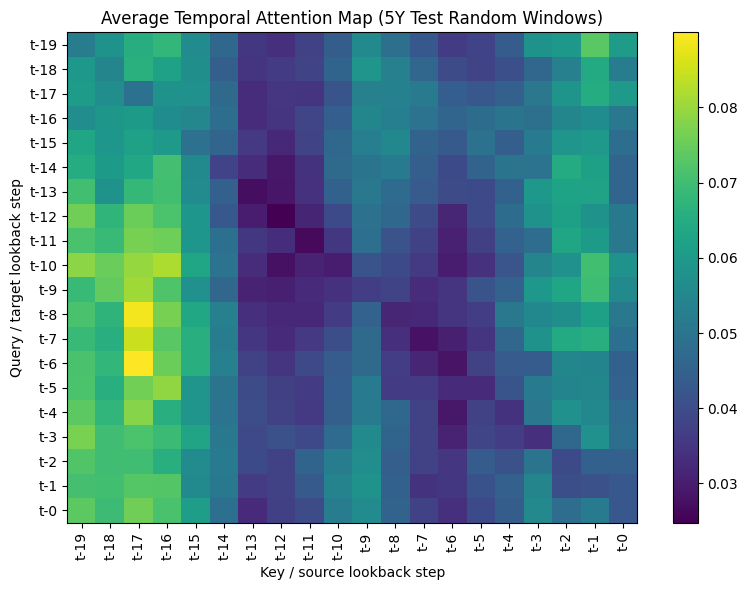

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y/avg_attention_random_windows_5y.png


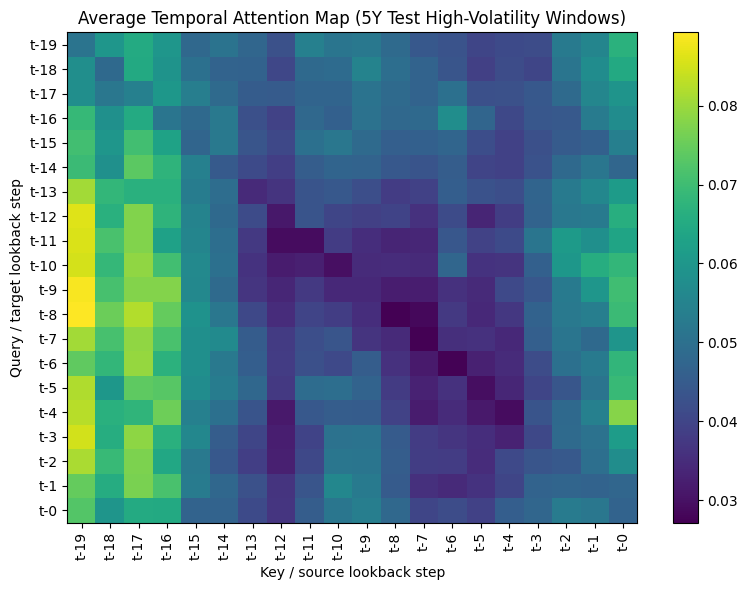

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y/avg_attention_high_vol_windows_5y.png


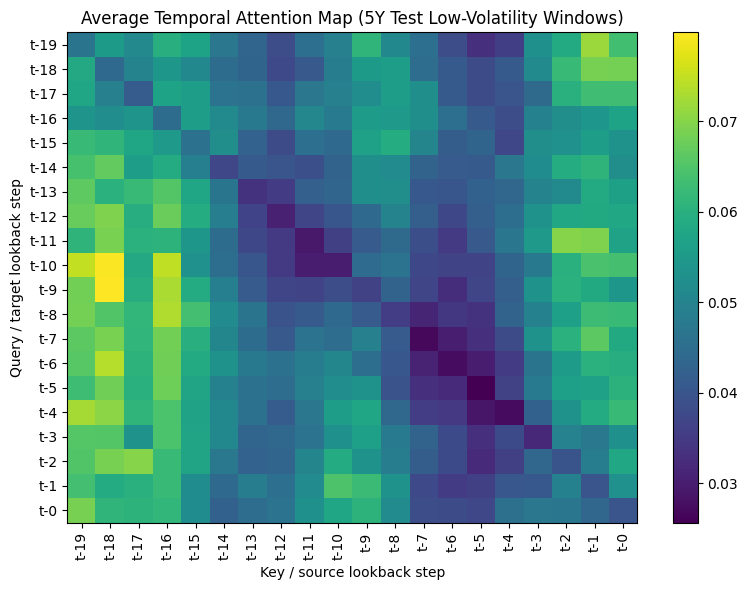

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y/avg_attention_low_vol_windows_5y.png


In [15]:
# ============================================================
# CELL 14 — Plot average temporal attention maps
# ============================================================

def make_time_labels(L):
    return [f"t-{L-1-i}" for i in range(L)]

def plot_attention_map(attn_map, title, save_name):
    L = attn_map.shape[0]
    labels = make_time_labels(L)

    plt.figure(figsize=(8, 6))
    plt.imshow(attn_map, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Key / source lookback step")
    plt.ylabel("Query / target lookback step")

    tick_positions = np.arange(L)
    plt.xticks(tick_positions, labels, rotation=90)
    plt.yticks(tick_positions, labels)

    plt.tight_layout()
    save_path = f"{OUTPUTS_EXPLAIN_AVG_DIR}/{save_name}"
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

plot_attention_map(
    avg_random_map,
    "Average Temporal Attention Map (5Y Test Random Windows)",
    "avg_attention_random_windows_5y.png"
)

plot_attention_map(
    avg_top_map,
    "Average Temporal Attention Map (5Y Test High-Volatility Windows)",
    "avg_attention_high_vol_windows_5y.png"
)

plot_attention_map(
    avg_bottom_map,
    "Average Temporal Attention Map (5Y Test Low-Volatility Windows)",
    "avg_attention_low_vol_windows_5y.png"
)

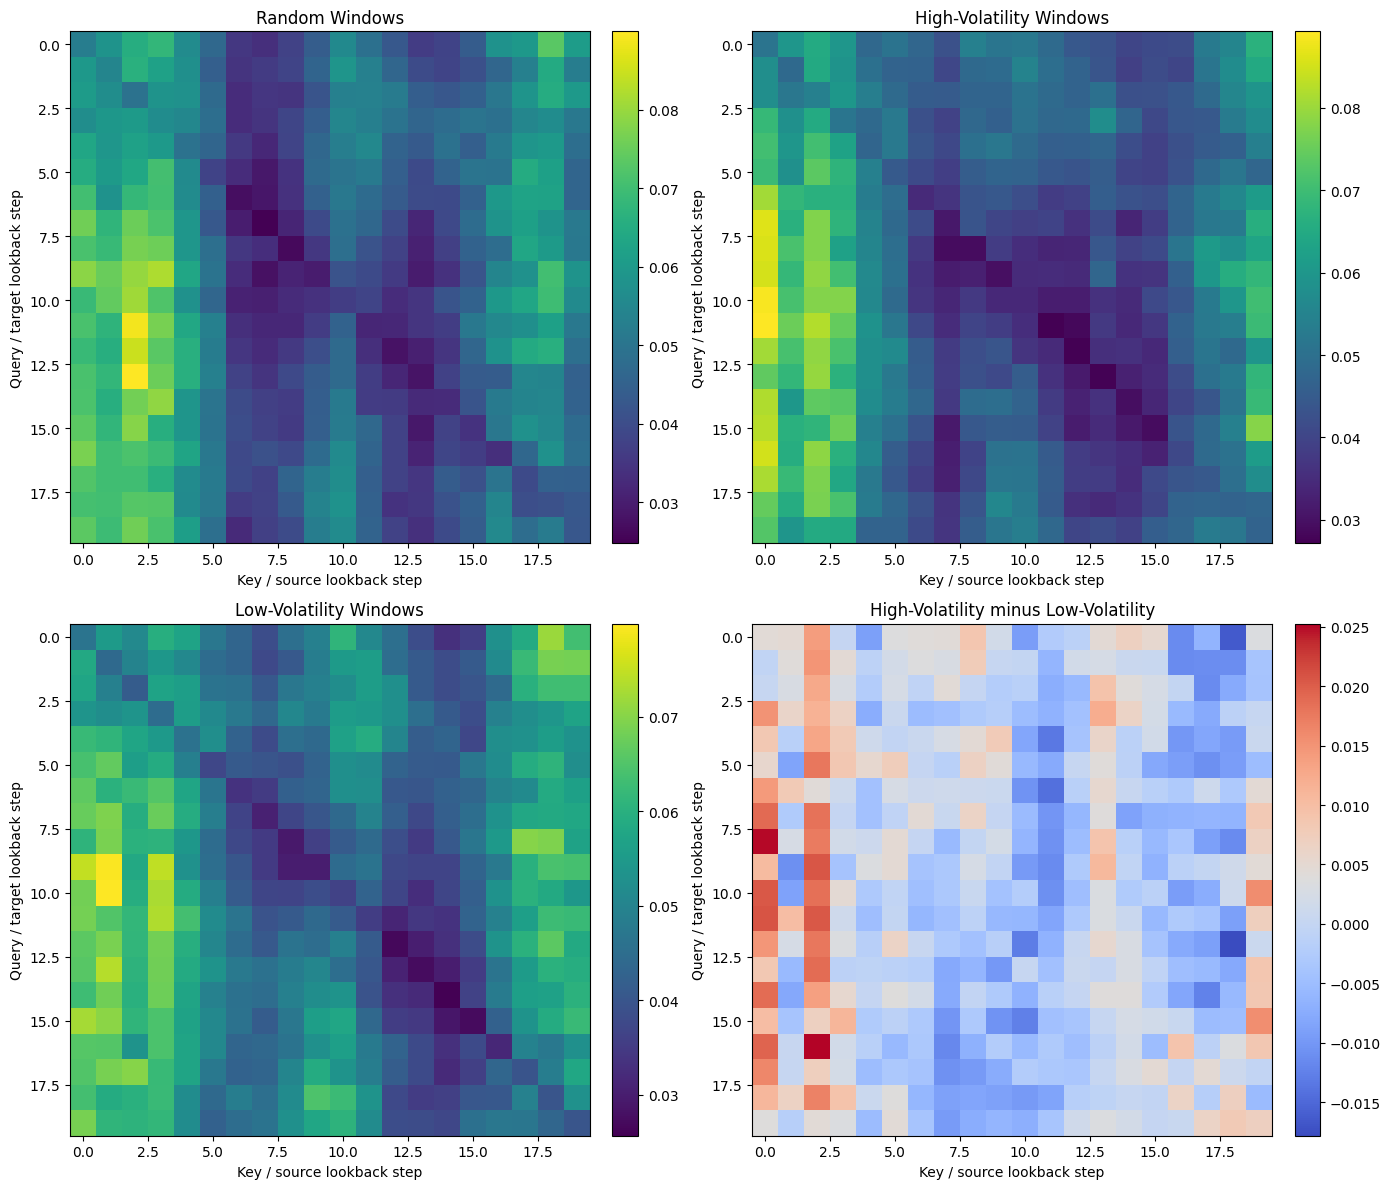

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im = axes[0, 0].imshow(avg_random_map, aspect="auto")
axes[0, 0].set_title("Random Windows")
axes[0, 0].set_xlabel("Key / source lookback step")
axes[0, 0].set_ylabel("Query / target lookback step")
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

im = axes[0, 1].imshow(avg_top_map, aspect="auto")
axes[0, 1].set_title("High-Volatility Windows")
axes[0, 1].set_xlabel("Key / source lookback step")
axes[0, 1].set_ylabel("Query / target lookback step")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

im = axes[1, 0].imshow(avg_bottom_map, aspect="auto")
axes[1, 0].set_title("Low-Volatility Windows")
axes[1, 0].set_xlabel("Key / source lookback step")
axes[1, 0].set_ylabel("Query / target lookback step")
fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

diff_map = avg_top_map - avg_bottom_map
im = axes[1, 1].imshow(diff_map, aspect="auto", cmap="coolwarm")
axes[1, 1].set_title("High-Volatility minus Low-Volatility")
axes[1, 1].set_xlabel("Key / source lookback step")
axes[1, 1].set_ylabel("Query / target lookback step")
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attention_grouped_overview_5y.png", dpi=300, bbox_inches="tight")
plt.show()

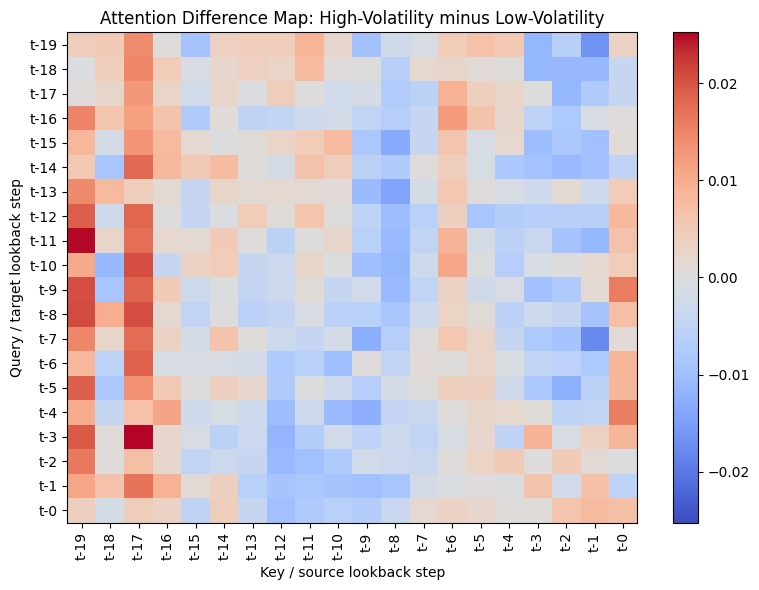

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y/diff_attention_high_minus_low_5y.png


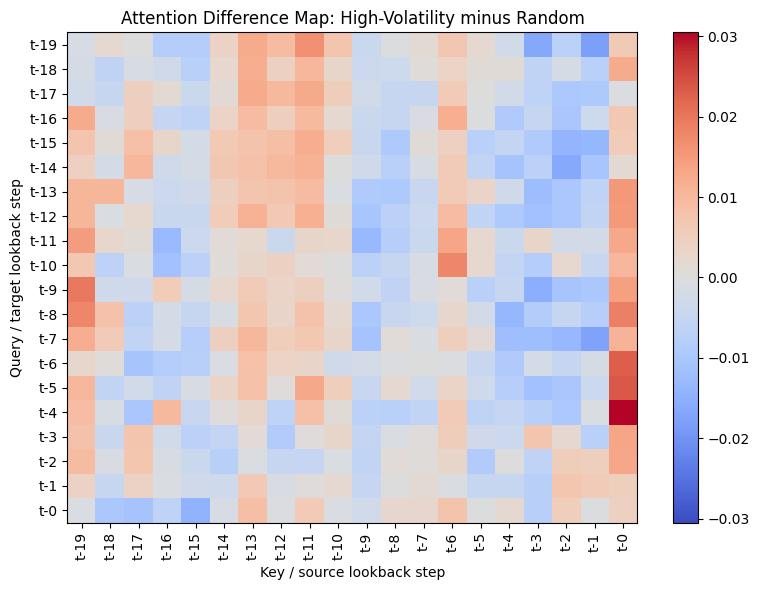

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y/diff_attention_high_minus_random_5y.png


In [17]:
# ============================================================
# CELL 15 — Plot attention difference maps
# ============================================================

diff_top_minus_bottom = avg_top_map - avg_bottom_map
diff_top_minus_random = avg_top_map - avg_random_map

def plot_diff_map(attn_map, title, save_name):
    L = attn_map.shape[0]
    labels = make_time_labels(L)

    vmax = np.max(np.abs(attn_map))
    vmin = -vmax

    plt.figure(figsize=(8, 6))
    plt.imshow(attn_map, aspect="auto", vmin=vmin, vmax=vmax, cmap="coolwarm")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Key / source lookback step")
    plt.ylabel("Query / target lookback step")

    tick_positions = np.arange(L)
    plt.xticks(tick_positions, labels, rotation=90)
    plt.yticks(tick_positions, labels)

    plt.tight_layout()
    save_path = f"{OUTPUTS_EXPLAIN_AVG_DIR}/{save_name}"
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.savefig(f"{FIG_DIR}/attention_diff_group.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

plot_diff_map(
    diff_top_minus_bottom,
    "Attention Difference Map: High-Volatility minus Low-Volatility",
    "diff_attention_high_minus_low_5y.png"
)

plot_diff_map(
    diff_top_minus_random,
    "Attention Difference Map: High-Volatility minus Random",
    "diff_attention_high_minus_random_5y.png"
)

In [18]:
import numpy as np
import pandas as pd

# =========================================================
# EXPECTED INPUTS
# Replace these variable names if needed to match your notebook:
#
# all_attn_maps : list or array of attention maps, shape [num_windows, L, L]
# vol_scores    : 1D array of volatility scores for each window, length num_windows
#
# Example meaning:
# - all_attn_maps[i] is the temporal attention map for test window i
# - vol_scores[i] is the volatility score used to rank/select windows
# =========================================================

# =========================================================
# Generate all_attn_maps and vol_scores
# =========================================================
all_attn_maps = []
for i in range(len(X_test)):
    result = run_attention_for_index(i)
    all_attn_maps.append(result["aggregate"])

vol_scores = market_move_score

# ---------- helper functions ----------
def normalize_rows(mat, eps=1e-12):
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return mat / row_sums

def mean_entropy(mat, eps=1e-12):
    p = normalize_rows(mat, eps=eps)
    ent = -np.sum(p * np.log(p + eps), axis=1)
    return ent.mean()

def recent_k_share(mat, k=5, eps=1e-12):
    p = normalize_rows(mat, eps=eps)
    return p[:, -k:].sum(axis=1).mean()

def center_of_mass(mat, eps=1e-12):
    p = normalize_rows(mat, eps=eps)
    cols = np.arange(p.shape[1], dtype=float)
    return (p * cols[None, :]).sum(axis=1).mean()

# ---------- convert to arrays ----------
maps = np.array(all_attn_maps, dtype=float)
vols = np.array(vol_scores, dtype=float)

assert len(maps) == len(vols), "all_attn_maps and vol_scores must have the same length"

# ---------- choose extreme groups ----------
top_q = 0.10       # top 10% high-vol
bottom_q = 0.10    # bottom 10% low-vol

high_thr = np.quantile(vols, 1 - top_q)
low_thr  = np.quantile(vols, bottom_q)

high_idx = np.where(vols >= high_thr)[0]
low_idx  = np.where(vols <= low_thr)[0]

print(f"Total windows: {len(vols)}")
print(f"High-vol windows: {len(high_idx)}")
print(f"Low-vol windows: {len(low_idx)}")

# ---------- compute per-window stats ----------
rows = []

for idx in high_idx:
    mat = maps[idx]
    rows.append({
        "window_index": int(idx),
        "group": "High-volatility",
        "vol_score": float(vols[idx]),
        "mean_entropy": float(mean_entropy(mat)),
        "recent_3_share": float(recent_k_share(mat, k=3)),
        "recent_5_share": float(recent_k_share(mat, k=5)),
        "recent_center_of_mass": float(center_of_mass(mat)),
    })

for idx in low_idx:
    mat = maps[idx]
    rows.append({
        "window_index": int(idx),
        "group": "Low-volatility",
        "vol_score": float(vols[idx]),
        "mean_entropy": float(mean_entropy(mat)),
        "recent_3_share": float(recent_k_share(mat, k=3)),
        "recent_5_share": float(recent_k_share(mat, k=5)),
        "recent_center_of_mass": float(center_of_mass(mat)),
    })

per_window_stats_df = pd.DataFrame(rows)
display(per_window_stats_df.head())

# ---------- grouped summary ----------
attention_regime_summary_df = (
    per_window_stats_df
    .groupby("group")
    .agg(
        n_windows=("window_index", "count"),
        mean_entropy_mean=("mean_entropy", "mean"),
        mean_entropy_std=("mean_entropy", "std"),
        recent_3_share_mean=("recent_3_share", "mean"),
        recent_3_share_std=("recent_3_share", "std"),
        recent_5_share_mean=("recent_5_share", "mean"),
        recent_5_share_std=("recent_5_share", "std"),
        recent_center_of_mass_mean=("recent_center_of_mass", "mean"),
        recent_center_of_mass_std=("recent_center_of_mass", "std"),
    )
    .reset_index()
)

display(attention_regime_summary_df)

# ---------- save tables ----------
per_window_stats_df.to_csv(f"{TAB_DIR}/attention_per_window_stats_5y.csv", index=False)
attention_regime_summary_df.to_csv(f"{TAB_DIR}/attention_regime_summary_5y.csv", index=False)

print("Saved:")
print(f"- {TAB_DIR}/attention_per_window_stats_5y.csv")
print(f"- {TAB_DIR}/attention_regime_summary_5y.csv")

# ---------- quick interpretation ----------
high_row = attention_regime_summary_df[
    attention_regime_summary_df["group"] == "High-volatility"
].iloc[0]
low_row = attention_regime_summary_df[
    attention_regime_summary_df["group"] == "Low-volatility"
].iloc[0]

print("\nInterpretation hints:")
if high_row["mean_entropy_mean"] > low_row["mean_entropy_mean"]:
    print("- High-volatility windows show higher mean attention entropy on average, which is consistent with more broadly dispersed temporal attention.")
else:
    print("- High-volatility windows do not show higher mean attention entropy on average in this comparison.")

if low_row["recent_5_share_mean"] > high_row["recent_5_share_mean"]:
    print("- Low-volatility windows allocate more attention mass to recent positions, which is consistent with more recent-focused attention under relatively stable regimes.")
else:
    print("- Low-volatility windows do not show stronger recent-step attention share in this comparison.")

if low_row["recent_center_of_mass_mean"] > high_row["recent_center_of_mass_mean"]:
    print("- Low-volatility windows also have a later source-position center of mass, reinforcing the recent-focus interpretation.")
else:
    print("- The center-of-mass comparison does not reinforce stronger recent focus for low-volatility windows.")

Total windows: 251
High-vol windows: 26
Low-vol windows: 26


,window_index,group,vol_score,mean_entropy,recent_3_share,recent_5_share,recent_center_of_mass
0,21,High-volatility,0.023861,2.907699,0.159008,0.225521,8.773616
1,34,High-volatility,0.018694,2.887319,0.147909,0.212021,8.256877
2,42,High-volatility,0.017666,2.875474,0.178123,0.252007,8.737117
3,69,High-volatility,0.022275,2.844693,0.150112,0.216564,7.648814
4,74,High-volatility,0.018111,2.887820,0.144783,0.280343,9.002841


,group,n_windows,mean_entropy_mean,mean_entropy_std,recent_3_share_mean,recent_3_share_std,recent_5_share_mean,recent_5_share_std,recent_center_of_mass_mean,recent_center_of_mass_std
0,High-volatility,26,2.876433,0.033661,0.168397,0.030446,0.253046,0.033761,8.953140,0.638394
1,Low-volatility,26,2.857357,0.035257,0.170315,0.047316,0.255322,0.057131,9.018252,0.812569


Saved:
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_per_window_stats_5y.csv
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_regime_summary_5y.csv

Interpretation hints:
- High-volatility windows show higher mean attention entropy on average, which is consistent with more broadly dispersed temporal attention.
- Low-volatility windows allocate more attention mass to recent positions, which is consistent with more recent-focused attention under relatively stable regimes.
- Low-volatility windows also have a later source-position center of mass, reinforcing the recent-focus interpretation.


In [21]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=attention_regime_summary_df)

https://docs.google.com/spreadsheets/d/19aeQNiwVY7waMlNbjoNn7856asTv_pyrwVnLUUYvDg4/edit#gid=0


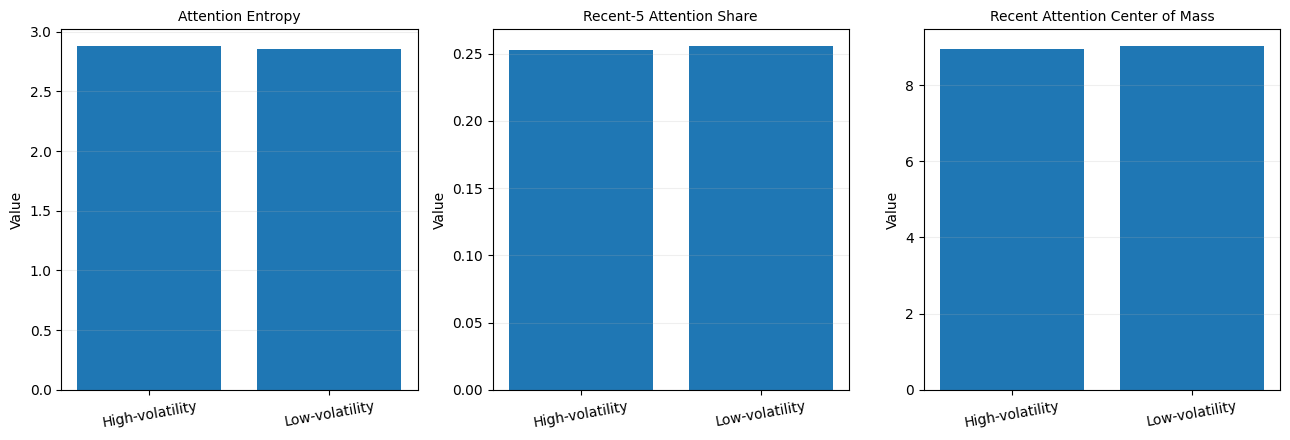

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5/attention_regime_stats_5y.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

plot_metrics = [
    ("mean_entropy_mean", "Attention Entropy"),
    ("recent_5_share_mean", "Recent-5 Attention Share"),
    ("recent_center_of_mass_mean", "Recent Attention Center of Mass"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (col, title) in zip(axes, plot_metrics):
    vals = attention_regime_summary_df[col].values
    labels = attention_regime_summary_df["group"].values
    bars = ax.bar(labels, vals)

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=10)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attention_regime_stats_5y.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", f"{FIG_DIR}/attention_regime_stats_5y.png")

In [23]:
# ============================================================
# CELL 16 — Build summary tables
# ============================================================

meta_all = pd.concat([meta_random, meta_top, meta_bottom], axis=0, ignore_index=True)

group_summary = meta_all.groupby("group").agg({
    "attention_mean": ["mean", "std"],
    "attention_std": ["mean", "std"],
    "attention_max": ["mean", "std"],
    "attention_min": ["mean", "std"],
    "attention_entropy": ["mean", "std"],
    "recent_5_share": ["mean", "std"],
    "diagonal_share": ["mean", "std"],
}).reset_index()

group_summary.columns = [
    "group",
    "attention_mean_mean", "attention_mean_std",
    "attention_std_mean", "attention_std_std",
    "attention_max_mean", "attention_max_std",
    "attention_min_mean", "attention_min_std",
    "attention_entropy_mean", "attention_entropy_std",
    "recent_5_share_mean", "recent_5_share_std",
    "diagonal_share_mean", "diagonal_share_std",
]

display(meta_all.head())
display(group_summary)

,group,sample_index,date,attention_mean,attention_std,attention_max,attention_min,attention_entropy,recent_5_share,diagonal_share
0,random_test_windows,6,2024-01-10,0.050373,0.038740,0.279180,0.009219,2.781743,0.207268,0.038436
1,random_test_windows,9,2024-01-16,0.049829,0.031783,0.225675,0.006588,2.834794,0.301839,0.038013
2,random_test_windows,10,2024-01-17,0.050038,0.025669,0.182288,0.011521,2.878167,0.316403,0.042835
3,random_test_windows,15,2024-01-24,0.050033,0.019740,0.129342,0.004281,2.919400,0.323920,0.042773
4,random_test_windows,19,2024-01-30,0.050437,0.020827,0.146450,0.015074,2.918152,0.246863,0.040805


,group,attention_mean_mean,attention_mean_std,attention_std_mean,attention_std_std,attention_max_mean,attention_max_std,attention_min_mean,attention_min_std,attention_entropy_mean,attention_entropy_std,recent_5_share_mean,recent_5_share_std,diagonal_share_mean,diagonal_share_std
0,high_volatility_windows,0.050084,0.000473,0.027462,0.005690,0.191409,0.045694,0.009433,0.003088,2.864402,0.044940,0.248445,0.044005,0.038713,0.004119
1,low_volatility_windows,0.050045,0.000463,0.029284,0.004364,0.202263,0.050858,0.009992,0.002726,2.852393,0.033878,0.259829,0.054989,0.035671,0.003383
2,random_test_windows,0.050157,0.000445,0.029253,0.005437,0.212883,0.047674,0.010037,0.003176,2.852524,0.041952,0.260617,0.057339,0.037677,0.003140


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [24]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=group_summary)

https://docs.google.com/spreadsheets/d/19W7CSLiwO1vakGP-f3IvRaNmS7Q5kmdQXxDF3MAPTMk/edit#gid=0


In [25]:
# ============================================================
# CELL 17 — Per-window regime summary stats (high-vol vs low-vol)
# Insert right after current CELL 16
# ============================================================

import numpy as np
import pandas as pd

# Use the per-window metadata already created in CELL 13
# meta_top     -> high_volatility_windows
# meta_bottom  -> low_volatility_windows

high_df = meta_top.copy()
low_df = meta_bottom.copy()

# recent_center_of_mass is not in meta_top/meta_bottom yet, so compute it from index
# using the grouped indices and run_attention_for_index again

def normalize_rows(mat, eps=1e-12):
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return mat / row_sums

def recent_center_of_mass(attn_map, eps=1e-12):
    p = normalize_rows(attn_map, eps=eps)
    cols = np.arange(p.shape[1], dtype=float)
    return float((p * cols[None, :]).sum(axis=1).mean())

# compute center of mass for high-vol group
high_com_rows = []
for idx in top_indices:
    result = run_attention_for_index(int(idx))
    agg = result["aggregate"]
    high_com_rows.append({
        "sample_index": int(idx),
        "recent_center_of_mass": recent_center_of_mass(agg)
    })

high_com_df = pd.DataFrame(high_com_rows)

# compute center of mass for low-vol group
low_com_rows = []
for idx in bottom_indices:
    result = run_attention_for_index(int(idx))
    agg = result["aggregate"]
    low_com_rows.append({
        "sample_index": int(idx),
        "recent_center_of_mass": recent_center_of_mass(agg)
    })

low_com_df = pd.DataFrame(low_com_rows)

# merge back
high_df = high_df.merge(high_com_df, on="sample_index", how="left")
low_df = low_df.merge(low_com_df, on="sample_index", how="left")

# rename group labels for cleaner reporting
high_df["group"] = "High-volatility"
low_df["group"] = "Low-volatility"

per_window_regime_df = pd.concat([high_df, low_df], axis=0, ignore_index=True)

attention_regime_summary_df = (
    per_window_regime_df
    .groupby("group")
    .agg(
        n_windows=("sample_index", "count"),
        mean_entropy_mean=("attention_entropy", "mean"),
        mean_entropy_std=("attention_entropy", "std"),
        recent_5_share_mean=("recent_5_share", "mean"),
        recent_5_share_std=("recent_5_share", "std"),
        diagonal_share_mean=("diagonal_share", "mean"),
        diagonal_share_std=("diagonal_share", "std"),
        recent_center_of_mass_mean=("recent_center_of_mass", "mean"),
        recent_center_of_mass_std=("recent_center_of_mass", "std"),
    )
    .reset_index()
)

print(f"Total windows used: {len(per_window_regime_df)}")
print(f"High-vol windows: {(per_window_regime_df['group'] == 'High-volatility').sum()}")
print(f"Low-vol windows: {(per_window_regime_df['group'] == 'Low-volatility').sum()}")

display(per_window_regime_df.head())
display(attention_regime_summary_df)

per_window_regime_df.to_csv(f"{TAB_DIR}/attention_per_window_regime_5y.csv", index=False)
attention_regime_summary_df.to_csv(f"{TAB_DIR}/attention_regime_summary_5y.csv", index=False)

print("Saved:")
print(f"- {TAB_DIR}/attention_per_window_regime_5y.csv")
print(f"- {TAB_DIR}/attention_regime_summary_5y.csv")

Total windows used: 60
High-vol windows: 30
Low-vol windows: 30


,group,sample_index,date,attention_mean,attention_std,attention_max,attention_min,attention_entropy,recent_5_share,diagonal_share,recent_center_of_mass
0,High-volatility,19,2024-01-30,0.049712,0.019003,0.134721,0.014226,2.929896,0.235886,0.037596,9.218880
1,High-volatility,21,2024-02-01,0.050122,0.024953,0.225118,0.010783,2.893346,0.233852,0.043443,8.832740
2,High-volatility,34,2024-02-21,0.049994,0.025866,0.181113,0.009768,2.879987,0.216963,0.035901,7.990298
3,High-volatility,42,2024-03-04,0.050291,0.026670,0.149881,0.009311,2.870084,0.248203,0.048598,8.619605
4,High-volatility,68,2024-04-10,0.050654,0.041592,0.277626,0.007764,2.749039,0.169483,0.037219,7.063664


,group,n_windows,mean_entropy_mean,mean_entropy_std,recent_5_share_mean,recent_5_share_std,diagonal_share_mean,diagonal_share_std,recent_center_of_mass_mean,recent_center_of_mass_std
0,High-volatility,30,2.864402,0.044940,0.248445,0.044005,0.038713,0.004119,8.798183,0.792115
1,Low-volatility,30,2.852393,0.033878,0.259829,0.054989,0.035671,0.003383,9.020901,0.794533


Saved:
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_per_window_regime_5y.csv
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_regime_summary_5y.csv


In [26]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=attention_regime_summary_df)

https://docs.google.com/spreadsheets/d/1Gl5vMkbfPY1qgt959UBCp2LOwVUd0CtUFxp046BmnUY/edit#gid=0


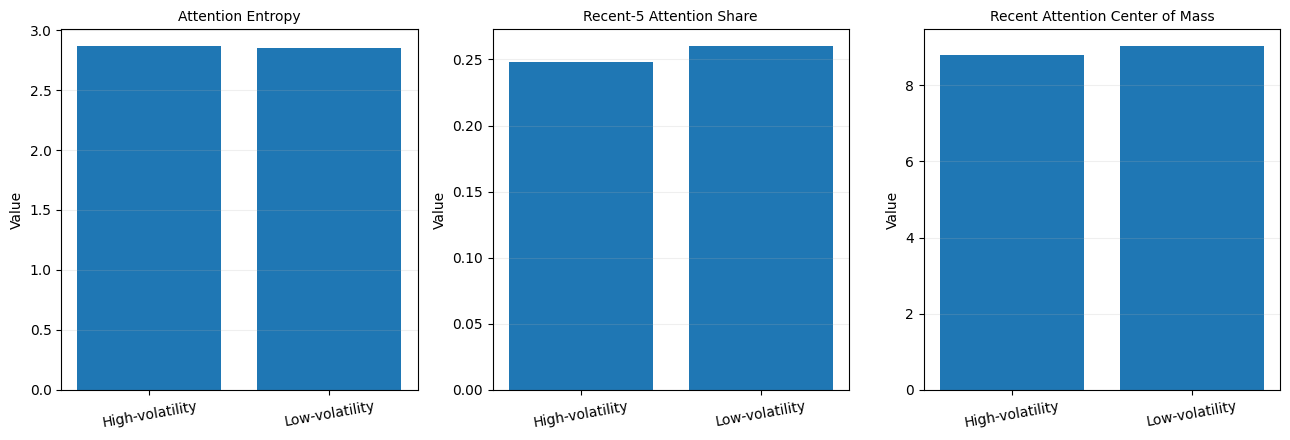

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5/attention_regime_stats_5y.png


In [27]:
# ============================================================
# CELL 18 — Regime summary figure
# Insert right after new CELL 17
# ============================================================

import matplotlib.pyplot as plt

plot_metrics = [
    ("mean_entropy_mean", "Attention Entropy"),
    ("recent_5_share_mean", "Recent-5 Attention Share"),
    ("recent_center_of_mass_mean", "Recent Attention Center of Mass"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (col, title) in zip(axes, plot_metrics):
    vals = attention_regime_summary_df[col].values
    labels = attention_regime_summary_df["group"].values
    ax.bar(labels, vals)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=10)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attention_regime_stats_5y.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", f"{FIG_DIR}/attention_regime_stats_5y.png")

In [28]:
# ============================================================
# CELL 19 — Delta table
# Insert right after new CELL 18
# ============================================================

high_row = attention_regime_summary_df[
    attention_regime_summary_df["group"] == "High-volatility"
].iloc[0]

low_row = attention_regime_summary_df[
    attention_regime_summary_df["group"] == "Low-volatility"
].iloc[0]

attention_regime_delta_df = pd.DataFrame({
    "comparison": ["High-vol minus Low-vol", "Low-vol minus High-vol"],
    "entropy_diff": [
        high_row["mean_entropy_mean"] - low_row["mean_entropy_mean"],
        low_row["mean_entropy_mean"] - high_row["mean_entropy_mean"],
    ],
    "recent_5_share_diff": [
        high_row["recent_5_share_mean"] - low_row["recent_5_share_mean"],
        low_row["recent_5_share_mean"] - high_row["recent_5_share_mean"],
    ],
    "diagonal_share_diff": [
        high_row["diagonal_share_mean"] - low_row["diagonal_share_mean"],
        low_row["diagonal_share_mean"] - high_row["diagonal_share_mean"],
    ],
    "recent_center_of_mass_diff": [
        high_row["recent_center_of_mass_mean"] - low_row["recent_center_of_mass_mean"],
        low_row["recent_center_of_mass_mean"] - high_row["recent_center_of_mass_mean"],
    ],
})

display(attention_regime_delta_df)
attention_regime_delta_df.to_csv(f"{TAB_DIR}/attention_regime_delta_5y.csv", index=False)

print("Saved:", f"{TAB_DIR}/attention_regime_delta_5y.csv")

,comparison,entropy_diff,recent_5_share_diff,diagonal_share_diff,recent_center_of_mass_diff
0,High-vol minus Low-vol,0.012008,-0.011384,0.003042,-0.222718
1,Low-vol minus High-vol,-0.012008,0.011384,-0.003042,0.222718


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_regime_delta_5y.csv


In [29]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=attention_regime_delta_df)

https://docs.google.com/spreadsheets/d/17PAENjcA4_wHjqiNtnC1xW6joTb8xuJTTtzILB_ld6Q/edit#gid=0


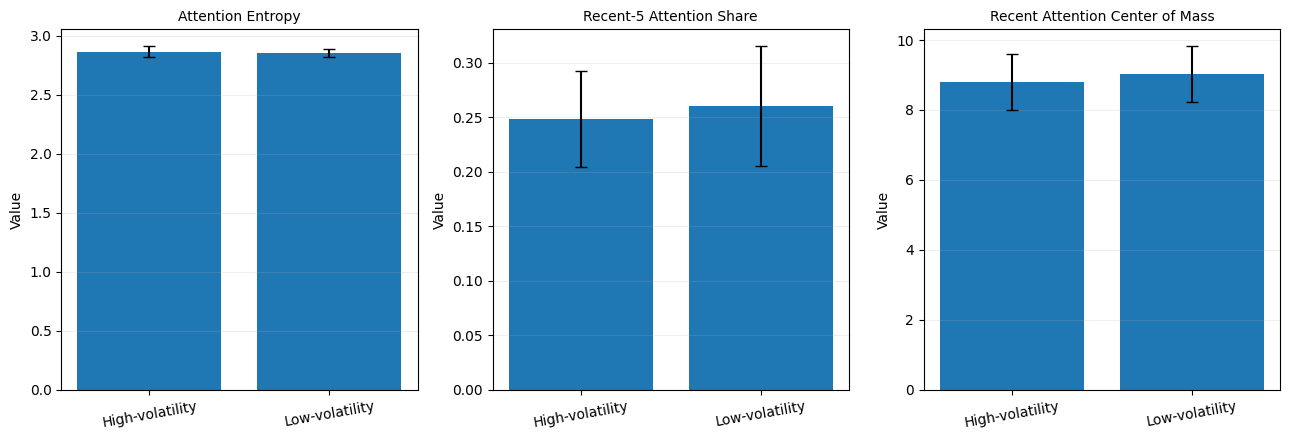

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5/attention_regime_errorbar_5y.png


In [30]:
# ============================================================
# CELL 20 — Error-bar figure
# Insert right after new CELL 19
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plot_specs = [
    ("mean_entropy_mean", "mean_entropy_std", "Attention Entropy"),
    ("recent_5_share_mean", "recent_5_share_std", "Recent-5 Attention Share"),
    ("recent_center_of_mass_mean", "recent_center_of_mass_std", "Recent Attention Center of Mass"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (mean_col, std_col, title) in zip(axes, plot_specs):
    means = attention_regime_summary_df[mean_col].values
    stds = attention_regime_summary_df[std_col].values
    labels = attention_regime_summary_df["group"].values
    x = np.arange(len(labels))

    ax.bar(x, means, yerr=stds, capsize=4)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Value")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=10)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attention_regime_errorbar_5y.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", f"{FIG_DIR}/attention_regime_errorbar_5y.png")

In [31]:
# ============================================================
# CELL 21 — Statistical tests
# Insert right after new CELL 20
# ============================================================

from scipy.stats import ttest_ind, mannwhitneyu
import pandas as pd

high_df = per_window_regime_df[per_window_regime_df["group"] == "High-volatility"].copy()
low_df  = per_window_regime_df[per_window_regime_df["group"] == "Low-volatility"].copy()

metric_map = {
    "attention_entropy": "mean_entropy",
    "recent_5_share": "recent_5_share",
    "diagonal_share": "diagonal_share",
    "recent_center_of_mass": "recent_center_of_mass",
}

rows = []

for col, metric_name in metric_map.items():
    high_vals = high_df[col].values
    low_vals = low_df[col].values

    t_stat, t_p = ttest_ind(high_vals, low_vals, equal_var=False)
    u_stat, u_p = mannwhitneyu(high_vals, low_vals, alternative="two-sided")

    rows.append({
        "metric": metric_name,
        "high_mean": high_vals.mean(),
        "low_mean": low_vals.mean(),
        "mean_diff_high_minus_low": high_vals.mean() - low_vals.mean(),
        "welch_t_pvalue": t_p,
        "mannwhitney_pvalue": u_p,
    })

attention_regime_tests_df = pd.DataFrame(rows)
display(attention_regime_tests_df)

attention_regime_tests_df.to_csv(f"{TAB_DIR}/attention_regime_tests_5y.csv", index=False)
print("Saved:", f"{TAB_DIR}/attention_regime_tests_5y.csv")

,metric,high_mean,low_mean,mean_diff_high_minus_low,welch_t_pvalue,mannwhitney_pvalue
0,mean_entropy,2.864402,2.852393,0.012008,0.247673,0.171450
1,recent_5_share,0.248445,0.259829,-0.011384,0.379812,0.347828
2,diagonal_share,0.038713,0.035671,0.003042,0.002817,0.000952
3,recent_center_of_mass,8.798183,9.020901,-0.222718,0.281402,0.446419


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_regime_tests_5y.csv


In [32]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=attention_regime_tests_df)

https://docs.google.com/spreadsheets/d/14OSKSVkk_yClTie_BeJRIytmfS8UJdQU1jqASZYViHU/edit#gid=0


In [33]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

# per_window_regime_df must already exist from previous cells
# and must contain a column 'sample_index' plus group labels

def normalize_rows(mat, eps=1e-12):
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return mat / row_sums

def recent_k_share(attn_map, k=5, eps=1e-12):
    p = normalize_rows(attn_map, eps=eps)
    return float(p[:, -k:].sum(axis=1).mean())

# rebuild recent-k metrics per window from the original attention maps
# using sample_index and run_attention_for_index()

ks = [1, 3, 5, 7, 10]
rows = []

for _, row in per_window_regime_df.iterrows():
    idx = int(row["sample_index"])
    grp = row["group"]

    result = run_attention_for_index(idx)
    agg = result["aggregate"]

    rec = {
        "sample_index": idx,
        "group": grp,
    }
    for k in ks:
        rec[f"recent_{k}_share"] = recent_k_share(agg, k=k)
    rows.append(rec)

recent_k_df = pd.DataFrame(rows)

# merge into a wider table if you want
display(recent_k_df.head())

test_rows = []

high_df = recent_k_df[recent_k_df["group"] == "High-volatility"].copy()
low_df  = recent_k_df[recent_k_df["group"] == "Low-volatility"].copy()

for k in ks:
    col = f"recent_{k}_share"
    high_vals = high_df[col].values
    low_vals = low_df[col].values

    # two-sided Welch
    _, p_two = ttest_ind(high_vals, low_vals, equal_var=False)

    # one-sided Welch approximation from t-stat sign
    t_stat, _ = ttest_ind(low_vals, high_vals, equal_var=False)  # low > high hypothesis
    p_one = p_two / 2 if t_stat > 0 else 1 - (p_two / 2)

    # Mann-Whitney one-sided: low > high
    _, p_u_one = mannwhitneyu(low_vals, high_vals, alternative="greater")
    _, p_u_two = mannwhitneyu(low_vals, high_vals, alternative="two-sided")

    test_rows.append({
        "metric": col,
        "high_mean": high_vals.mean(),
        "low_mean": low_vals.mean(),
        "mean_diff_low_minus_high": low_vals.mean() - high_vals.mean(),
        "welch_two_sided_p": p_two,
        "welch_one_sided_p_low_gt_high": p_one,
        "mannwhitney_two_sided_p": p_u_two,
        "mannwhitney_one_sided_p_low_gt_high": p_u_one,
    })

recent_focus_tests_df = pd.DataFrame(test_rows)
display(recent_focus_tests_df)

recent_k_df.to_csv(f"{TAB_DIR}/attention_recent_k_per_window_5y.csv", index=False)
recent_focus_tests_df.to_csv(f"{TAB_DIR}/attention_recent_k_tests_5y.csv", index=False)

print("Saved:")
print(f"- {TAB_DIR}/attention_recent_k_per_window_5y.csv")
print(f"- {TAB_DIR}/attention_recent_k_tests_5y.csv")

,sample_index,group,recent_1_share,recent_3_share,recent_5_share,recent_7_share,recent_10_share
0,19,High-volatility,0.064193,0.135922,0.229002,0.323527,0.457683
1,21,High-volatility,0.038182,0.161102,0.224560,0.301220,0.453224
2,34,High-volatility,0.037172,0.123373,0.196059,0.267850,0.378923
3,42,High-volatility,0.064899,0.189120,0.249772,0.305706,0.490702
4,68,High-volatility,0.035109,0.104480,0.168835,0.218535,0.346457


,metric,high_mean,low_mean,mean_diff_low_minus_high,welch_two_sided_p,welch_one_sided_p_low_gt_high,mannwhitney_two_sided_p,mannwhitney_one_sided_p_low_gt_high
0,recent_1_share,0.057596,0.058804,0.001208,0.827947,0.413974,0.673495,0.336748
1,recent_3_share,0.162860,0.174031,0.011172,0.291662,0.145831,0.482517,0.241258
2,recent_5_share,0.243449,0.260249,0.016800,0.173557,0.086779,0.277189,0.138595
3,recent_7_share,0.322273,0.331958,0.009685,0.478769,0.239385,0.482517,0.241258
4,recent_10_share,0.447607,0.465797,0.018190,0.241704,0.120852,0.304177,0.152088


Saved:
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_recent_k_per_window_5y.csv
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_recent_k_tests_5y.csv


In [34]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=recent_focus_tests_df)

https://docs.google.com/spreadsheets/d/1hcSpe5PaUDP_4YTC-8-wmpyZsNBby6mwlFt7k3ey3OM/edit#gid=0


In [35]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

def normalize_rows(mat, eps=1e-12):
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return mat / row_sums

def mean_entropy(mat, eps=1e-12):
    p = normalize_rows(mat, eps=eps)
    return float((-np.sum(p * np.log(p + eps), axis=1)).mean())

def recent_k_share(attn_map, k=5, eps=1e-12):
    p = normalize_rows(attn_map, eps=eps)
    return float(p[:, -k:].sum(axis=1).mean())

# Use all test indices and volatility scores already available in notebook
# You may need to replace test_indices_all and vol_scores_all with real names
# Here we reconstruct from sample_metrics_df if available:
sample_metrics_df = pd.DataFrame({
    "sample_index": np.arange(len(market_move_score)),
    "volatility": market_move_score
})
all_df = sample_metrics_df.copy()

thresholds = [0.10, 0.15, 0.20, 0.25]
rows = []

for q in thresholds:
    high_thr = all_df["volatility"].quantile(1 - q)
    low_thr = all_df["volatility"].quantile(q)

    high_ids = all_df.loc[all_df["volatility"] >= high_thr, "sample_index"].tolist()
    low_ids  = all_df.loc[all_df["volatility"] <= low_thr, "sample_index"].tolist()

    high_entropy_vals = []
    low_entropy_vals = []
    high_recent_vals = []
    low_recent_vals = []

    for idx in high_ids:
        result = run_attention_for_index(int(idx))
        agg = result["aggregate"]
        high_entropy_vals.append(mean_entropy(agg))
        high_recent_vals.append(recent_k_share(agg, k=5))

    for idx in low_ids:
        result = run_attention_for_index(int(idx))
        agg = result["aggregate"]
        low_entropy_vals.append(mean_entropy(agg))
        low_recent_vals.append(recent_k_share(agg, k=5))

    _, p_entropy = ttest_ind(high_entropy_vals, low_entropy_vals, equal_var=False)
    _, p_recent = ttest_ind(low_recent_vals, high_recent_vals, equal_var=False)

    rows.append({
        "quantile_each_side": q,
        "n_high": len(high_ids),
        "n_low": len(low_ids),
        "entropy_high_mean": np.mean(high_entropy_vals),
        "entropy_low_mean": np.mean(low_entropy_vals),
        "entropy_diff_high_minus_low": np.mean(high_entropy_vals) - np.mean(low_entropy_vals),
        "entropy_p_two_sided": p_entropy,
        "recent5_high_mean": np.mean(high_recent_vals),
        "recent5_low_mean": np.mean(low_recent_vals),
        "recent5_diff_low_minus_high": np.mean(low_recent_vals) - np.mean(high_recent_vals),
        "recent5_p_two_sided": p_recent,
    })

threshold_sweep_df = pd.DataFrame(rows)
display(threshold_sweep_df)
threshold_sweep_df.to_csv(f"{TAB_DIR}/attention_regime_threshold_sweep_5y.csv", index=False)

print("Saved:", f"{TAB_DIR}/attention_regime_threshold_sweep_5y.csv")

,quantile_each_side,n_high,n_low,entropy_high_mean,entropy_low_mean,entropy_diff_high_minus_low,entropy_p_two_sided,recent5_high_mean,recent5_low_mean,recent5_diff_low_minus_high,recent5_p_two_sided
0,0.10,26,26,2.873114,2.852111,0.021004,0.051029,0.251801,0.254513,0.002713,0.844030
1,0.15,38,38,2.868678,2.855244,0.013434,0.110352,0.243795,0.255125,0.011330,0.294824
2,0.20,51,51,2.864991,2.856551,0.008440,0.265675,0.247698,0.253235,0.005537,0.551424
3,0.25,63,63,2.869226,2.858313,0.010912,0.096314,0.251028,0.257664,0.006636,0.483060


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_regime_threshold_sweep_5y.csv


In [36]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=threshold_sweep_df)

https://docs.google.com/spreadsheets/d/1JHuXxAzwfzaLnLxoETWdCTp_VJxlCkafyQwDkGSJBkA/edit#gid=0


In [37]:
# ============================================================
# CELL 22 — Stronger recent-focus metrics
# Insert right after current CELL 21
# ============================================================

import numpy as np
import pandas as pd

def normalize_rows(mat, eps=1e-12):
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return mat / row_sums

def recent_old_ratio(attn_map, recent_k=5, old_k=5, eps=1e-12):
    p = normalize_rows(attn_map, eps=eps)
    recent = p[:, -recent_k:].sum(axis=1).mean()
    old = p[:, :old_k].sum(axis=1).mean()
    return float(recent / (old + eps))

def recency_slope(attn_map, eps=1e-12):
    """
    Positive slope => more weight on later / more recent source positions.
    """
    p = normalize_rows(attn_map, eps=eps)
    cols = np.arange(p.shape[1], dtype=float)
    avg_col_weight = p.mean(axis=0)
    # simple linear slope
    x = cols - cols.mean()
    y = avg_col_weight - avg_col_weight.mean()
    slope = (x * y).sum() / ((x * x).sum() + eps)
    return float(slope)

rows = []

for _, row in per_window_regime_df.iterrows():
    idx = int(row["sample_index"])
    grp = row["group"]
    result = run_attention_for_index(idx)
    agg = result["aggregate"]

    rows.append({
        "sample_index": idx,
        "group": grp,
        "recent_old_ratio_3v3": recent_old_ratio(agg, recent_k=3, old_k=3),
        "recent_old_ratio_5v5": recent_old_ratio(agg, recent_k=5, old_k=5),
        "recency_slope": recency_slope(agg),
    })

recent_focus_extra_df = pd.DataFrame(rows)
display(recent_focus_extra_df.head())

extra_summary_df = (
    recent_focus_extra_df
    .groupby("group")
    .agg(
        n_windows=("sample_index", "count"),
        ratio_3v3_mean=("recent_old_ratio_3v3", "mean"),
        ratio_3v3_std=("recent_old_ratio_3v3", "std"),
        ratio_5v5_mean=("recent_old_ratio_5v5", "mean"),
        ratio_5v5_std=("recent_old_ratio_5v5", "std"),
        recency_slope_mean=("recency_slope", "mean"),
        recency_slope_std=("recency_slope", "std"),
    )
    .reset_index()
)

display(extra_summary_df)

recent_focus_extra_df.to_csv(f"{TAB_DIR}/attention_recent_focus_extra_5y.csv", index=False)
extra_summary_df.to_csv(f"{TAB_DIR}/attention_recent_focus_extra_summary_5y.csv", index=False)

print("Saved:")
print(f"- {TAB_DIR}/attention_recent_focus_extra_5y.csv")
print(f"- {TAB_DIR}/attention_recent_focus_extra_summary_5y.csv")

,sample_index,group,recent_old_ratio_3v3,recent_old_ratio_5v5,recency_slope
0,19,High-volatility,0.949903,0.754498,-0.000408
1,21,High-volatility,0.665044,0.665976,-0.001323
2,34,High-volatility,0.546663,0.554339,-0.002289
3,42,High-volatility,0.937380,0.814850,-0.000537
4,68,High-volatility,0.281148,0.340901,-0.003990


,group,n_windows,ratio_3v3_mean,ratio_3v3_std,ratio_5v5_mean,ratio_5v5_std,recency_slope_mean,recency_slope_std
0,High-volatility,30,0.867577,0.310277,0.787530,0.246085,-0.000965,0.001241
1,Low-volatility,30,0.957985,0.327060,0.876634,0.303057,-0.000669,0.001165


Saved:
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_recent_focus_extra_5y.csv
- /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_recent_focus_extra_summary_5y.csv


In [41]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=extra_summary_df)

https://docs.google.com/spreadsheets/d/1Dql3oUVsG9ntycaDYPtHZMT2KBMkE2yOnZJ2em05xww/edit#gid=0


In [38]:
# ============================================================
# CELL 23 — One-sided permutation tests
# Insert right after CELL 22
# ============================================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

def permutation_test_one_sided(x, y, alternative="x_gt_y", n_perm=20000, seed=42):
    """
    alternative:
      - 'x_gt_y': test mean(x) > mean(y)
      - 'y_gt_x': test mean(y) > mean(x)
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    obs = x.mean() - y.mean()
    pooled = np.concatenate([x, y])
    n_x = len(x)

    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        x_perm = perm[:n_x]
        y_perm = perm[n_x:]
        diff = x_perm.mean() - y_perm.mean()

        if alternative == "x_gt_y":
            if diff >= obs:
                count += 1
        elif alternative == "y_gt_x":
            if -diff >= -obs:
                count += 1
        else:
            raise ValueError("alternative must be 'x_gt_y' or 'y_gt_x'")

    p = (count + 1) / (n_perm + 1)
    return obs, p

high_main = per_window_regime_df[per_window_regime_df["group"] == "High-volatility"].copy()
low_main  = per_window_regime_df[per_window_regime_df["group"] == "Low-volatility"].copy()

high_extra = recent_focus_extra_df[recent_focus_extra_df["group"] == "High-volatility"].copy()
low_extra  = recent_focus_extra_df[recent_focus_extra_df["group"] == "Low-volatility"].copy()

rows = []

# High-vol broader: entropy high > low
obs, p = permutation_test_one_sided(
    high_main["attention_entropy"].values,
    low_main["attention_entropy"].values,
    alternative="x_gt_y",
    n_perm=20000,
    seed=42
)
rows.append({
    "metric": "attention_entropy",
    "directional_hypothesis": "high_vol > low_vol",
    "observed_diff_high_minus_low": obs,
    "permutation_one_sided_p": p,
})

# Stable regime more recent-focused: low > high
for col in ["recent_5_share", "recent_center_of_mass"]:
    obs, p = permutation_test_one_sided(
        low_main[col].values,
        high_main[col].values,
        alternative="x_gt_y",
        n_perm=20000,
        seed=42
    )
    rows.append({
        "metric": col,
        "directional_hypothesis": "low_vol > high_vol",
        "observed_diff_low_minus_high": obs,
        "permutation_one_sided_p": p,
    })

for col in ["recent_old_ratio_3v3", "recent_old_ratio_5v5", "recency_slope"]:
    obs, p = permutation_test_one_sided(
        low_extra[col].values,
        high_extra[col].values,
        alternative="x_gt_y",
        n_perm=20000,
        seed=42
    )
    rows.append({
        "metric": col,
        "directional_hypothesis": "low_vol > high_vol",
        "observed_diff_low_minus_high": obs,
        "permutation_one_sided_p": p,
    })

perm_tests_df = pd.DataFrame(rows)
display(perm_tests_df)
perm_tests_df.to_csv(f"{TAB_DIR}/attention_permutation_tests_5y.csv", index=False)

print("Saved:", f"{TAB_DIR}/attention_permutation_tests_5y.csv")

,metric,directional_hypothesis,observed_diff_high_minus_low,permutation_one_sided_p,observed_diff_low_minus_high
0,attention_entropy,high_vol > low_vol,0.012008,0.126594,NaN
1,recent_5_share,low_vol > high_vol,NaN,0.188391,0.011384
2,recent_center_of_mass,low_vol > high_vol,NaN,0.137393,0.222718
3,recent_old_ratio_3v3,low_vol > high_vol,NaN,0.130893,0.090408
4,recent_old_ratio_5v5,low_vol > high_vol,NaN,0.102545,0.089104
5,recency_slope,low_vol > high_vol,NaN,0.167742,0.000296


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_permutation_tests_5y.csv


In [42]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=perm_tests_df)

https://docs.google.com/spreadsheets/d/1s-YItM8Ou95YmIo1Ay6esq5P71kxu9DZOCe3_Lc7RFE/edit#gid=0


In [39]:
# ============================================================
# CELL 24 — Bootstrap confidence intervals
# Insert right after CELL 23
# ============================================================

import numpy as np
import pandas as pd

def bootstrap_ci_diff(a, b, n_boot=20000, seed=42, diff="a_minus_b"):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        a_s = rng.choice(a, size=len(a), replace=True)
        b_s = rng.choice(b, size=len(b), replace=True)
        if diff == "a_minus_b":
            diffs[i] = a_s.mean() - b_s.mean()
        elif diff == "b_minus_a":
            diffs[i] = b_s.mean() - a_s.mean()
        else:
            raise ValueError("diff must be 'a_minus_b' or 'b_minus_a'")

    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), lo, hi

rows = []

# entropy: high - low
mean_diff, lo, hi = bootstrap_ci_diff(
    high_main["attention_entropy"].values,
    low_main["attention_entropy"].values,
    diff="a_minus_b"
)
rows.append({
    "metric": "attention_entropy",
    "reported_diff": "high_minus_low",
    "boot_mean_diff": mean_diff,
    "ci_2_5": lo,
    "ci_97_5": hi,
})

# low - high for recent-focus metrics
for col in ["recent_5_share", "recent_center_of_mass"]:
    mean_diff, lo, hi = bootstrap_ci_diff(
        high_main[col].values,
        low_main[col].values,
        diff="b_minus_a"
    )
    rows.append({
        "metric": col,
        "reported_diff": "low_minus_high",
        "boot_mean_diff": mean_diff,
        "ci_2_5": lo,
        "ci_97_5": hi,
    })

for col in ["recent_old_ratio_3v3", "recent_old_ratio_5v5", "recency_slope"]:
    mean_diff, lo, hi = bootstrap_ci_diff(
        high_extra[col].values,
        low_extra[col].values,
        diff="b_minus_a"
    )
    rows.append({
        "metric": col,
        "reported_diff": "low_minus_high",
        "boot_mean_diff": mean_diff,
        "ci_2_5": lo,
        "ci_97_5": hi,
    })

bootstrap_ci_df = pd.DataFrame(rows)
display(bootstrap_ci_df)

bootstrap_ci_df.to_csv(f"{TAB_DIR}/attention_bootstrap_ci_5y.csv", index=False)
print("Saved:", f"{TAB_DIR}/attention_bootstrap_ci_5y.csv")

,metric,reported_diff,boot_mean_diff,ci_2_5,ci_97_5
0,attention_entropy,high_minus_low,0.012047,-0.007889,0.031404
1,recent_5_share,low_minus_high,0.011405,-0.013504,0.035872
2,recent_center_of_mass,low_minus_high,0.222811,-0.166705,0.621870
3,recent_old_ratio_3v3,low_minus_high,0.090040,-0.066744,0.250503
4,recent_old_ratio_5v5,low_minus_high,0.088731,-0.045266,0.229549
5,recency_slope,low_minus_high,0.000295,-0.000289,0.000904


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_bootstrap_ci_5y.csv


In [43]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=bootstrap_ci_df)

https://docs.google.com/spreadsheets/d/1iqzlH7uxhBM8BPMkp_1fctUfqIRXSIW-FzOq7YrUOI4/edit#gid=0


In [40]:
# ============================================================
# CELL 25 — Threshold sweep with stronger metrics
# Insert right after CELL 24
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# sample_metrics_df already exists in your notebook
# and includes columns: sample_index, volatility

def normalize_rows(mat, eps=1e-12):
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return mat / row_sums

def mean_entropy(attn_map, eps=1e-12):
    p = normalize_rows(attn_map, eps=eps)
    return float((-np.sum(p * np.log(p + eps), axis=1)).mean())

def recency_slope(attn_map, eps=1e-12):
    p = normalize_rows(attn_map, eps=eps)
    cols = np.arange(p.shape[1], dtype=float)
    avg_col_weight = p.mean(axis=0)
    x = cols - cols.mean()
    y = avg_col_weight - avg_col_weight.mean()
    return float((x * y).sum() / ((x * x).sum() + eps))

thresholds = [0.10, 0.15, 0.20, 0.25]
rows = []

for q in thresholds:
    high_thr = sample_metrics_df["volatility"].quantile(1 - q)
    low_thr  = sample_metrics_df["volatility"].quantile(q)

    high_ids = sample_metrics_df.loc[sample_metrics_df["volatility"] >= high_thr, "sample_index"].tolist()
    low_ids  = sample_metrics_df.loc[sample_metrics_df["volatility"] <= low_thr, "sample_index"].tolist()

    high_entropy_vals = []
    low_entropy_vals = []
    high_slope_vals = []
    low_slope_vals = []

    for idx in high_ids:
        agg = run_attention_for_index(int(idx))["aggregate"]
        high_entropy_vals.append(mean_entropy(agg))
        high_slope_vals.append(recency_slope(agg))

    for idx in low_ids:
        agg = run_attention_for_index(int(idx))["aggregate"]
        low_entropy_vals.append(mean_entropy(agg))
        low_slope_vals.append(recency_slope(agg))

    _, p_entropy = ttest_ind(high_entropy_vals, low_entropy_vals, equal_var=False)
    _, p_slope = ttest_ind(low_slope_vals, high_slope_vals, equal_var=False)

    rows.append({
        "quantile_each_side": q,
        "n_high": len(high_ids),
        "n_low": len(low_ids),
        "entropy_high_mean": np.mean(high_entropy_vals),
        "entropy_low_mean": np.mean(low_entropy_vals),
        "entropy_diff_high_minus_low": np.mean(high_entropy_vals) - np.mean(low_entropy_vals),
        "entropy_p_two_sided": p_entropy,
        "slope_high_mean": np.mean(high_slope_vals),
        "slope_low_mean": np.mean(low_slope_vals),
        "slope_diff_low_minus_high": np.mean(low_slope_vals) - np.mean(high_slope_vals),
        "slope_p_two_sided": p_slope,
    })

threshold_sweep_stronger_df = pd.DataFrame(rows)
display(threshold_sweep_stronger_df)
threshold_sweep_stronger_df.to_csv(f"{TAB_DIR}/attention_threshold_sweep_stronger_5y.csv", index=False)

print("Saved:", f"{TAB_DIR}/attention_threshold_sweep_stronger_5y.csv")

,quantile_each_side,n_high,n_low,entropy_high_mean,entropy_low_mean,entropy_diff_high_minus_low,entropy_p_two_sided,slope_high_mean,slope_low_mean,slope_diff_low_minus_high,slope_p_two_sided
0,0.10,26,26,2.870096,2.850355,0.019741,0.052926,-0.000873,-0.000806,0.000067,0.830427
1,0.15,38,38,2.868561,2.861148,0.007414,0.329225,-0.000965,-0.000759,0.000206,0.445037
2,0.20,51,51,2.864320,2.860651,0.003669,0.610103,-0.000872,-0.000701,0.000170,0.475347
3,0.25,63,63,2.864311,2.856935,0.007376,0.268320,-0.000808,-0.000684,0.000124,0.585747


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_threshold_sweep_stronger_5y.csv


In [44]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=threshold_sweep_stronger_df)

https://docs.google.com/spreadsheets/d/1IwLLmGGaNaLqgT735Q7EVp-rOg1tI3q8GyltwadEQao/edit#gid=0


In [45]:
# ============================================================
# CELL 26 — Sensitivity analysis for regime thresholds
# Insert right after current CELL 25
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

def normalize_rows(mat, eps=1e-12):
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return mat / row_sums

def mean_entropy(attn_map, eps=1e-12):
    p = normalize_rows(attn_map, eps=eps)
    return float((-np.sum(p * np.log(p + eps), axis=1)).mean())

# sample_metrics_df must already exist and contain:
# - sample_index
# - volatility

thresholds = [0.08, 0.10, 0.125, 0.15]

rows = []

for q in thresholds:
    high_thr = sample_metrics_df["volatility"].quantile(1 - q)
    low_thr  = sample_metrics_df["volatility"].quantile(q)

    high_ids = sample_metrics_df.loc[sample_metrics_df["volatility"] >= high_thr, "sample_index"].tolist()
    low_ids  = sample_metrics_df.loc[sample_metrics_df["volatility"] <= low_thr, "sample_index"].tolist()

    high_entropy_vals = []
    low_entropy_vals = []

    for idx in high_ids:
        agg = run_attention_for_index(int(idx))["aggregate"]
        high_entropy_vals.append(mean_entropy(agg))

    for idx in low_ids:
        agg = run_attention_for_index(int(idx))["aggregate"]
        low_entropy_vals.append(mean_entropy(agg))

    high_entropy_vals = np.array(high_entropy_vals, dtype=float)
    low_entropy_vals = np.array(low_entropy_vals, dtype=float)

    # two-sided Welch
    _, welch_p_two = ttest_ind(high_entropy_vals, low_entropy_vals, equal_var=False)

    # one-sided Welch for hypothesis high > low
    t_stat, p_two_tmp = ttest_ind(high_entropy_vals, low_entropy_vals, equal_var=False)
    welch_p_one_high_gt_low = p_two_tmp / 2 if t_stat > 0 else 1 - (p_two_tmp / 2)

    # Mann-Whitney
    _, mw_p_two = mannwhitneyu(high_entropy_vals, low_entropy_vals, alternative="two-sided")
    _, mw_p_one = mannwhitneyu(high_entropy_vals, low_entropy_vals, alternative="greater")

    rows.append({
        "quantile_each_side": q,
        "n_high": len(high_ids),
        "n_low": len(low_ids),
        "entropy_high_mean": high_entropy_vals.mean(),
        "entropy_low_mean": low_entropy_vals.mean(),
        "entropy_diff_high_minus_low": high_entropy_vals.mean() - low_entropy_vals.mean(),
        "welch_two_sided_p": welch_p_two,
        "welch_one_sided_p_high_gt_low": welch_p_one_high_gt_low,
        "mannwhitney_two_sided_p": mw_p_two,
        "mannwhitney_one_sided_p_high_gt_low": mw_p_one,
    })

entropy_sensitivity_df = pd.DataFrame(rows)
display(entropy_sensitivity_df)

entropy_sensitivity_df.to_csv(f"{TAB_DIR}/attention_entropy_sensitivity_5y.csv", index=False)
print("Saved:", f"{TAB_DIR}/attention_entropy_sensitivity_5y.csv")

,quantile_each_side,n_high,n_low,entropy_high_mean,entropy_low_mean,entropy_diff_high_minus_low,welch_two_sided_p,welch_one_sided_p_high_gt_low,mannwhitney_two_sided_p,mannwhitney_one_sided_p_high_gt_low
0,0.080,21,21,2.872284,2.851521,0.020763,0.133457,0.066728,0.118841,0.059421
1,0.100,26,26,2.873127,2.855958,0.017169,0.066869,0.033434,0.117641,0.058821
2,0.125,32,32,2.871246,2.853700,0.017546,0.087936,0.043968,0.089407,0.044703
3,0.150,38,38,2.866012,2.859585,0.006428,0.446358,0.223179,0.414778,0.207389


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/attention_entropy_sensitivity_5y.csv


In [46]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=entropy_sensitivity_df)

https://docs.google.com/spreadsheets/d/15vF8AC_xqjMEuCEGudMU795y-N5HPei7c-CI-HJUGhg/edit#gid=0


In [47]:
# ============================================================
# CELL 27 — Save summary tables
# ============================================================

meta_all.to_csv(f"{OUTPUTS_EXPLAIN_AVG_DIR}/attention_meta_all_5y.csv", index=False)
group_summary.to_csv(f"{OUTPUTS_EXPLAIN_AVG_DIR}/attention_group_summary_5y.csv", index=False)
group_summary.to_csv(f"{TAB_DIR}/attention_group_summary_5y.csv", index=False)

print("Saved:", f"{OUTPUTS_EXPLAIN_AVG_DIR}/attention_meta_all_5y.csv")
print("Saved:", f"{OUTPUTS_EXPLAIN_AVG_DIR}/attention_group_summary_5y.csv")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y/attention_meta_all_5y.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_average_5y/attention_group_summary_5y.csv


In [48]:
# ============================================================
# CELL 28 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_EXPLAIN_AVG_DIR}/avg_attention_random_windows_5y.png",
    f"{OUTPUTS_EXPLAIN_AVG_DIR}/avg_attention_high_vol_windows_5y.png",
    f"{OUTPUTS_EXPLAIN_AVG_DIR}/avg_attention_low_vol_windows_5y.png",
    f"{OUTPUTS_EXPLAIN_AVG_DIR}/diff_attention_high_minus_low_5y.png",
    f"{OUTPUTS_EXPLAIN_AVG_DIR}/diff_attention_high_minus_random_5y.png",
    f"{OUTPUTS_EXPLAIN_AVG_DIR}/attention_meta_all_5y.csv",
    f"{OUTPUTS_EXPLAIN_AVG_DIR}/attention_group_summary_5y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

print("Average attention notebook checks passed.")

Average attention notebook checks passed.
